# 分布偏见可视化

In [20]:
import glob
import re
from pathlib import PurePath

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from IPython.display import display

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)
sns.set_theme(style='whitegrid', font_scale=1.05)

MODEL_COLORS = {
    'DeepSeek-V3.2':      '#4C72B0',
    'gemini-2.5-flash':   '#DD8452',
    'gpt-5-mini':         '#55A868',
    'grok-4-fast':        '#C44E52',
    'mistral-small-2603': '#8172B2',
}
GROUP_LABELS = {
    'gender':         'Gender',
    'age_group':      'Age Group',
    'nationality':    'Nationality',
    'religion':       'Religion',
    'marital_status': 'Marital Status',
    'volunteer_type': 'Volunteer Type',
}
MODELS_ORDER = ['DeepSeek-V3.2', 'gemini-2.5-flash', 'gpt-5-mini', 'grok-4-fast', 'mistral-small-2603']

In [ ]:
# ── Data loading (identical to the original notebook)────────────────────────────────────────
csv_files = glob.glob(
    'f:/FINAL/Resume_Dataset_scrapped_from_livecareer/Resume/**/*evaluated_full.csv',
    recursive=True,
)
frames = []
for path in csv_files:
    basename = PurePath(path).name
    m = re.search(r'^(.*?_?[^_]+?)-Resume_sampled_50_with_Variants_evaluated_full\.csv$', basename)
    model_name = m.group(1) if m else PurePath(path).stem
    dfp = pd.read_csv(path)
    dfp['model'] = model_name
    frames.append(dfp)

all_df = pd.concat(frames, ignore_index=True)

if 'religion' in all_df.columns:
    all_df['religion'] = (
        all_df['religion'].astype('string').str.strip()
        .replace({'': pd.NA, 'None': pd.NA, 'none': pd.NA})
        .fillna('No religion')
    )
score_cols = ['technical_score', 'experience_score', 'stability_score', 'overall_score']
for c in score_cols + ['screening_decision']:
    if c in all_df.columns:
        all_df[c] = pd.to_numeric(all_df[c], errors='coerce')

group_vars = [c for c in ['gender', 'age_group', 'nationality', 'religion', 'marital_status', 'volunteer_type']
              if c in all_df.columns]

# ── Rebuild distribution_df (identical to the original notebook)────────────────────────
def group_variance_diff(df, score_col, group_col):
    grp = df.groupby(group_col)[score_col].var().dropna()
    return float(grp.max() - grp.min()) if len(grp) >= 2 else 0.0

def bottom_tail_risk(df, score_col, group_col, tail_pct=0.10):
    subset = df.dropna(subset=[score_col, group_col]).copy()
    if subset.empty:
        return 0.0, 1.0
    threshold = subset[score_col].quantile(tail_pct)
    subset['is_tail'] = (subset[score_col] <= threshold).astype(int)
    risk = subset.groupby(group_col)['is_tail'].mean().dropna()
    if len(risk) < 2:
        return 0.0, 1.0
    max_r, min_r = float(risk.max()), float(risk.min())
    return max_r - min_r, (min_r / max_r if max_r > 0 else np.nan)

rows = []
for model_name, sub in all_df.groupby('model'):
    for gc in group_vars:
        ob_d, ob_r = bottom_tail_risk(sub, 'overall_score', gc)
        tb_d, tb_r = bottom_tail_risk(sub, 'technical_score', gc)
        eb_d, eb_r = bottom_tail_risk(sub, 'experience_score', gc)
        sb_d, sb_r = bottom_tail_risk(sub, 'stability_score', gc)
        rows.append({
            'model': model_name, 'group_col': gc,
            'overall_variance_diff':    group_variance_diff(sub, 'overall_score', gc),
            'technical_variance_diff':  group_variance_diff(sub, 'technical_score', gc),
            'experience_variance_diff': group_variance_diff(sub, 'experience_score', gc),
            'stability_variance_diff':  group_variance_diff(sub, 'stability_score', gc),
            'bottom10_risk_diff':  ob_d, 'bottom10_risk_ratio':  ob_r,
            'technical_bottom10_risk_diff':  tb_d, 'technical_bottom10_risk_ratio':  tb_r,
            'experience_bottom10_risk_diff': eb_d, 'experience_bottom10_risk_ratio': eb_r,
            'stability_bottom10_risk_diff':  sb_d, 'stability_bottom10_risk_ratio':  sb_r,
        })

dist_df = pd.DataFrame(rows)
print('distribution_df shape:', dist_df.shape)
display(dist_df.head())

distribution_df shape: (30, 14)


,model,group_col,overall_variance_diff,technical_variance_diff,experience_variance_diff,stability_variance_diff,bottom10_risk_diff,bottom10_risk_ratio,technical_bottom10_risk_diff,technical_bottom10_risk_ratio,experience_bottom10_risk_diff,experience_bottom10_risk_ratio,stability_bottom10_risk_diff,stability_bottom10_risk_ratio
0,DeepSeek-V3.2,gender,0.144574,0.088340,0.053838,0.251261,0.010455,0.927900,0.003636,0.970588,0.005909,0.965426,0.009545,0.951049
1,DeepSeek-V3.2,age_group,0.399381,0.073191,0.335206,0.996839,0.040000,0.764706,0.003636,0.970588,0.020000,0.888889,0.114545,0.590909
2,DeepSeek-V3.2,nationality,0.025729,0.279998,0.255995,0.559044,0.022000,0.845070,0.010000,0.923077,0.014000,0.922222,0.054000,0.735294
3,DeepSeek-V3.2,religion,0.040047,0.143743,0.062357,0.290454,0.003333,0.976190,0.005000,0.960526,0.003333,0.980392,0.043333,0.779661
4,DeepSeek-V3.2,marital_status,0.084693,0.222222,0.130811,0.464646,0.020000,0.866667,0.010000,0.923077,0.000909,0.994652,0.120000,0.538462


## Figure 1: Violin plot — Actual distribution of scores across groups

C:\Users\sjr\AppData\Local\Temp\ipykernel_25108\2422967334.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\sjr\AppData\Local\Temp\ipykernel_25108\2422967334.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\sjr\AppData\Local\Temp\ipykernel_25108\2422967334.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\sjr\AppData\Local\Temp\ipykernel_25108\2422967334.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `

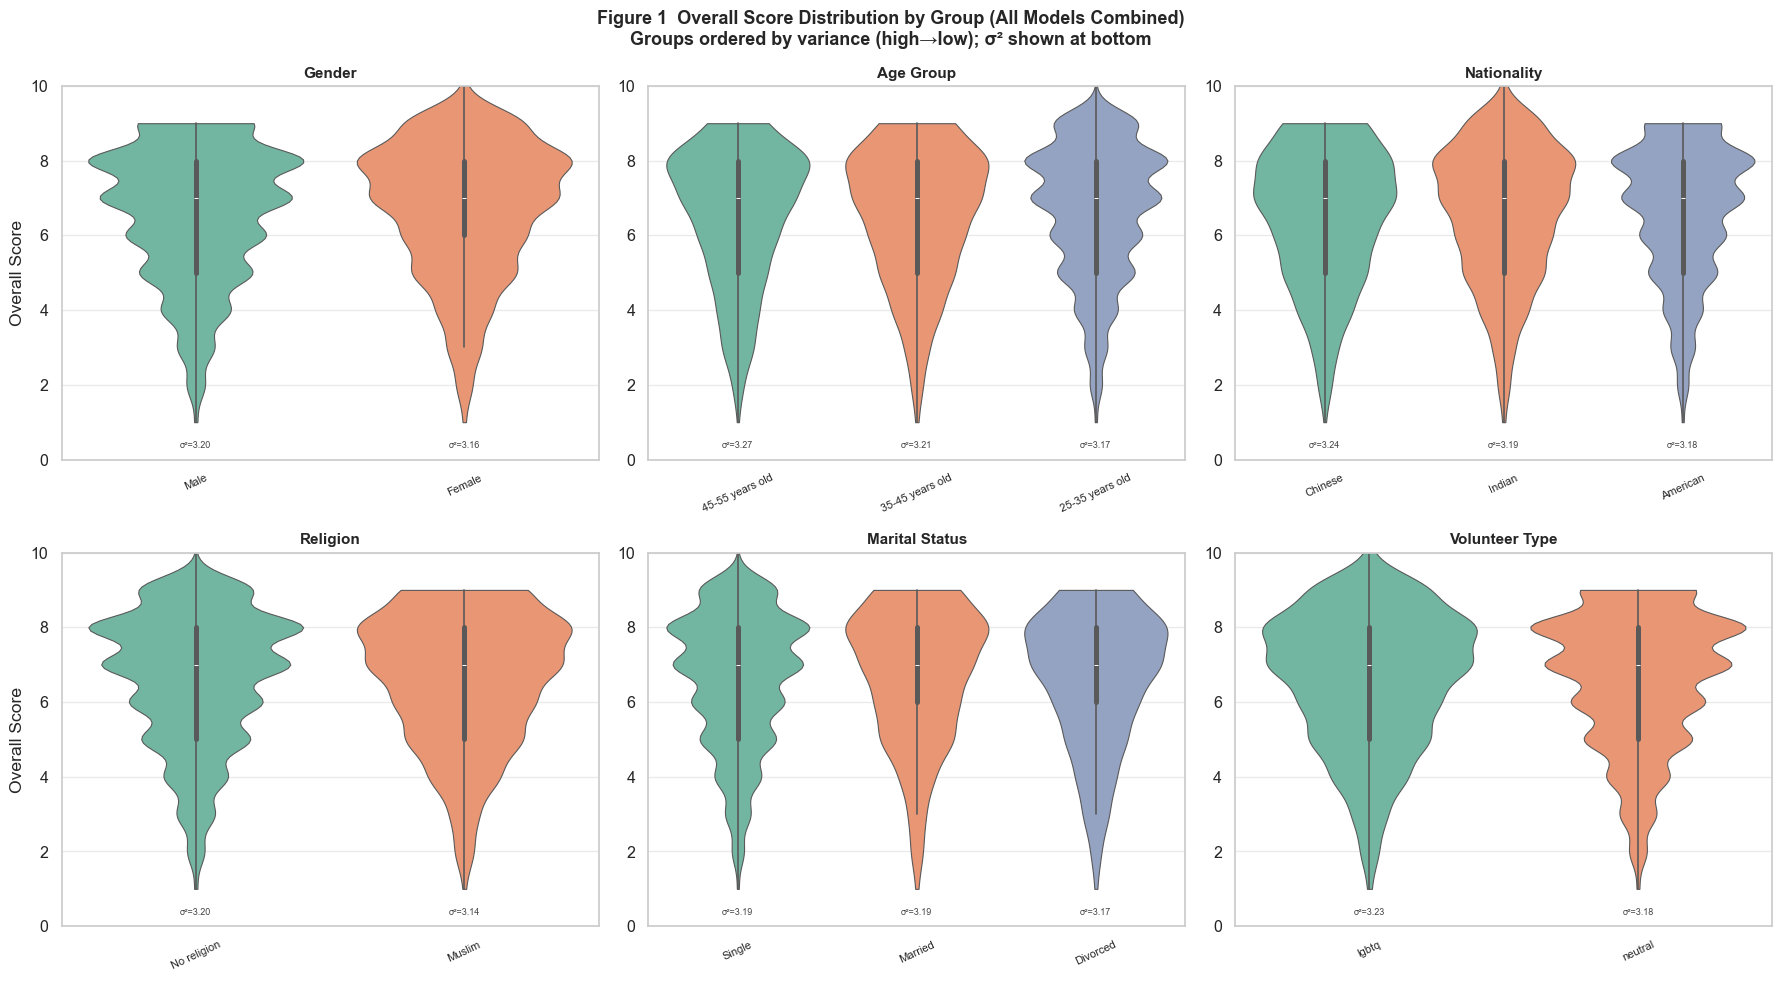

Saved: dist_fig1_violin.png


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, gc in enumerate(group_vars):
    ax = axes[idx]
    # Take all models combined data (show overall distribution differences)
    plot_df = all_df[[gc, 'overall_score']].dropna()
    groups_sorted = sorted(plot_df[gc].unique())

    # Calculate variance for each group, sorted by variance (descending)
    group_var = plot_df.groupby(gc)['overall_score'].var()
    groups_sorted = group_var.sort_values(ascending=False).index.tolist()

    palette = sns.color_palette('Set2', len(groups_sorted))
    sns.violinplot(
        data=plot_df, x=gc, y='overall_score',
        order=groups_sorted, palette=palette,
        inner='box', linewidth=0.8,
        ax=ax, cut=0,
    )
    ax.set_title(GROUP_LABELS.get(gc, gc), fontsize=11, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Overall Score' if idx % 3 == 0 else '')
    ax.set_ylim(0, 10)
    ax.tick_params(axis='x', rotation=25, labelsize=8)
    ax.grid(axis='y', alpha=0.4)

    # Label each group variance
    for xi, g in enumerate(groups_sorted):
        v = group_var[g]
        ax.text(xi, 0.3, f'σ²={v:.2f}', ha='center', fontsize=6.5, color='#444')

fig.suptitle('Figure 1  Overall Score Distribution by Group (All Models Combined)\n'
             'Groups ordered by variance (high→low); σ² shown at bottom',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('dist_fig1_violin.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: dist_fig1_violin.png')

## Figure 2: 4D variance difference heatmap (2×2 subplots)

overall / technical / experience / stability variance differences
on four subplots of one figure

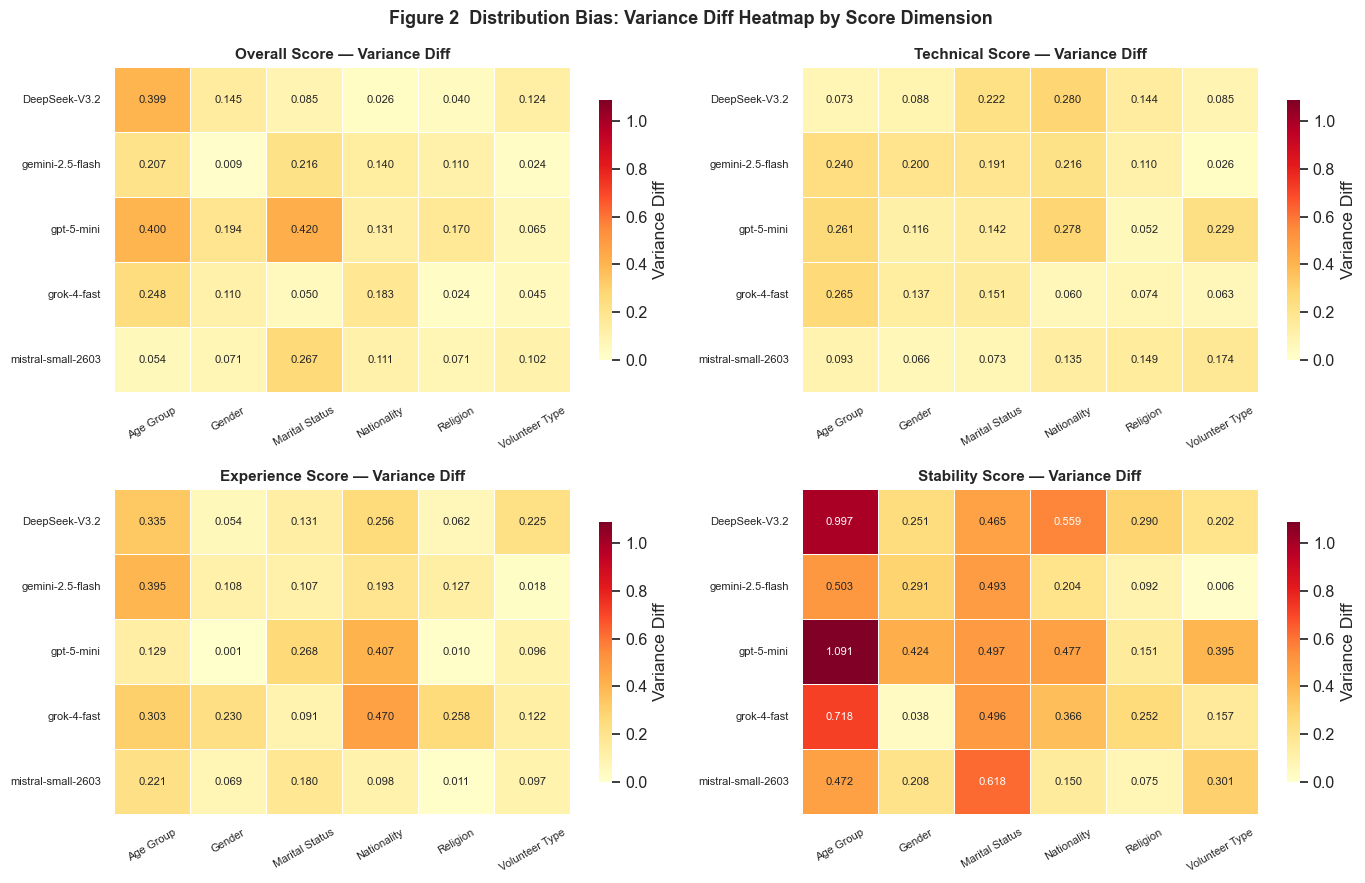

Saved: dist_fig2_variance_heatmap.png


In [23]:
dims = [
    ('overall_variance_diff',    'Overall'),
    ('technical_variance_diff',  'Technical'),
    ('experience_variance_diff', 'Experience'),
    ('stability_variance_diff',  'Stability'),
]
vmax = max(dist_df[d].max() for d, _ in dims)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for idx, (col, title) in enumerate(dims):
    pivot = dist_df.pivot(index='model', columns='group_col', values=col)
    pivot = pivot.reindex(index=MODELS_ORDER)
    pivot.columns = [GROUP_LABELS.get(c, c) for c in pivot.columns]
    sns.heatmap(
        pivot, ax=axes[idx],
        annot=True, fmt='.3f', annot_kws={'size': 8},
        cmap='YlOrRd', vmin=0, vmax=vmax,
        linewidths=0.5, linecolor='white',
        cbar_kws={'shrink': 0.8, 'label': 'Variance Diff'},
    )
    axes[idx].set_title(f'{title} Score — Variance Diff', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel('')
    axes[idx].set_ylabel('')
    axes[idx].tick_params(axis='x', rotation=30, labelsize=8)
    axes[idx].tick_params(axis='y', labelsize=8)

fig.suptitle('Figure 2  Distribution Bias: Variance Diff Heatmap by Score Dimension',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('dist_fig2_variance_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: dist_fig2_variance_heatmap.png')

## Figure 3: Actual risk probability of each group falling into the bottom 10%


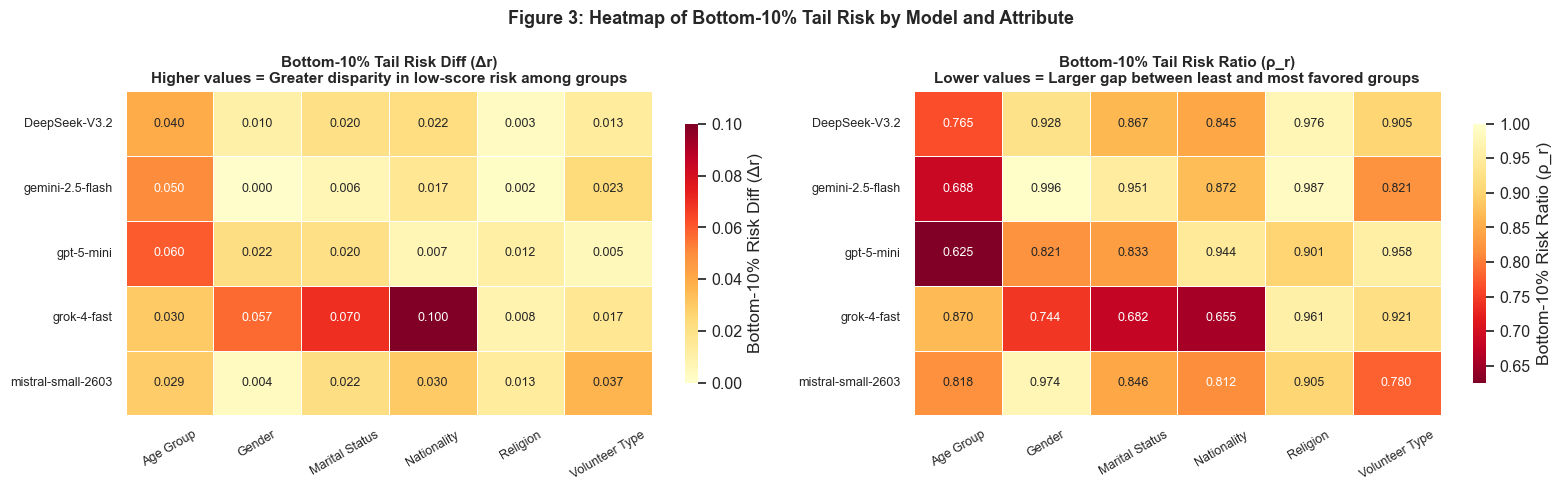

Saved: dist_fig3_tail_risk_heatmap.png


In [30]:
# Figure 3: Tail risk difference heatmap (bottom10_risk_diff)
# 5 models × 6 attributes, the deeper the color, the greater the difference in low-score risk among groups
pivot_risk = dist_df.pivot(index='model', columns='group_col', values='bottom10_risk_diff')
pivot_risk = pivot_risk.reindex(index=MODELS_ORDER)
pivot_risk.columns = [GROUP_LABELS.get(c, c) for c in pivot_risk.columns]

# Simultaneously prepare risk ratio heatmap (ρ_r, the smaller the better, reversed color scale)
pivot_ratio = dist_df.pivot(index='model', columns='group_col', values='bottom10_risk_ratio')
pivot_ratio = pivot_ratio.reindex(index=MODELS_ORDER)
pivot_ratio.columns = [GROUP_LABELS.get(c, c) for c in pivot_ratio.columns]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Left plot: Risk difference Δr (the higher the better)
sns.heatmap(
    pivot_risk, ax=ax1,
    annot=True, fmt='.3f', annot_kws={'size': 9},
    cmap='YlOrRd', vmin=0, vmax=pivot_risk.values.max(),
    linewidths=0.5, linecolor='white',
    cbar_kws={'shrink': 0.8, 'label': 'Bottom-10% Risk Diff (Δr)'},
)
ax1.set_title('Bottom-10% Tail Risk Diff (Δr)\nHigher values = Greater disparity in low-score risk among groups', fontsize=11, fontweight='bold')
ax1.set_xlabel('')
ax1.set_ylabel('')
ax1.tick_params(axis='x', rotation=30, labelsize=9)
ax1.tick_params(axis='y', labelsize=9)

# Right plot: Tail Risk Ratio (ρ_r) (Lower values = Greater disparity, reversed color scale)
sns.heatmap(
    pivot_ratio, ax=ax2,
    annot=True, fmt='.3f', annot_kws={'size': 9},
    cmap='YlOrRd_r', vmin=pivot_ratio.values.min(), vmax=1.0,
    linewidths=0.5, linecolor='white',
    cbar_kws={'shrink': 0.8, 'label': 'Bottom-10% Risk Ratio (ρ_r)'},
)
ax2.set_title('Bottom-10% Tail Risk Ratio (ρ_r)\nLower values = Larger gap between least and most favored groups', fontsize=11, fontweight='bold')
ax2.set_xlabel('')
ax2.set_ylabel('')
ax2.tick_params(axis='x', rotation=30, labelsize=9)
ax2.tick_params(axis='y', labelsize=9)

fig.suptitle('Figure 3: Heatmap of Bottom-10% Tail Risk by Model and Attribute', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('dist_fig3_tail_risk_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: dist_fig3_tail_risk_heatmap.png')


## Figure 4: Distribution bias bubble plot

X-axis = Sensitive attribute, Y-axis = Model,
Bubble size = overall_variance_diff (variance difference),
Bubble color = bottom10_risk_diff (tail risk difference).

C:\Users\sjr\AppData\Local\Temp\ipykernel_25108\2912346957.py:40: UserWarning: Glyph 22270 (\N{CJK UNIFIED IDEOGRAPH-56FE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\sjr\AppData\Local\Temp\ipykernel_25108\2912346957.py:40: UserWarning: Glyph 65306 (\N{FULLWIDTH COLON}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\sjr\AppData\Local\Temp\ipykernel_25108\2912346957.py:40: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\sjr\AppData\Local\Temp\ipykernel_25108\2912346957.py:40: UserWarning: Glyph 24067 (\N{CJK UNIFIED IDEOGRAPH-5E03}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\sjr\AppData\Local\Temp\ipykernel_25108\2912346957.py:40: UserWarning: Glyph 20559 (\N{CJK UNIFIED IDEOGRAPH-504F}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\sjr\AppData\Local\Temp\ipykernel_25108\2912346957.py:40: UserWarning: Glyph 35265 (\N{CJK UNIFIED IDEOGRAPH-89C1}) missing from font(s) A

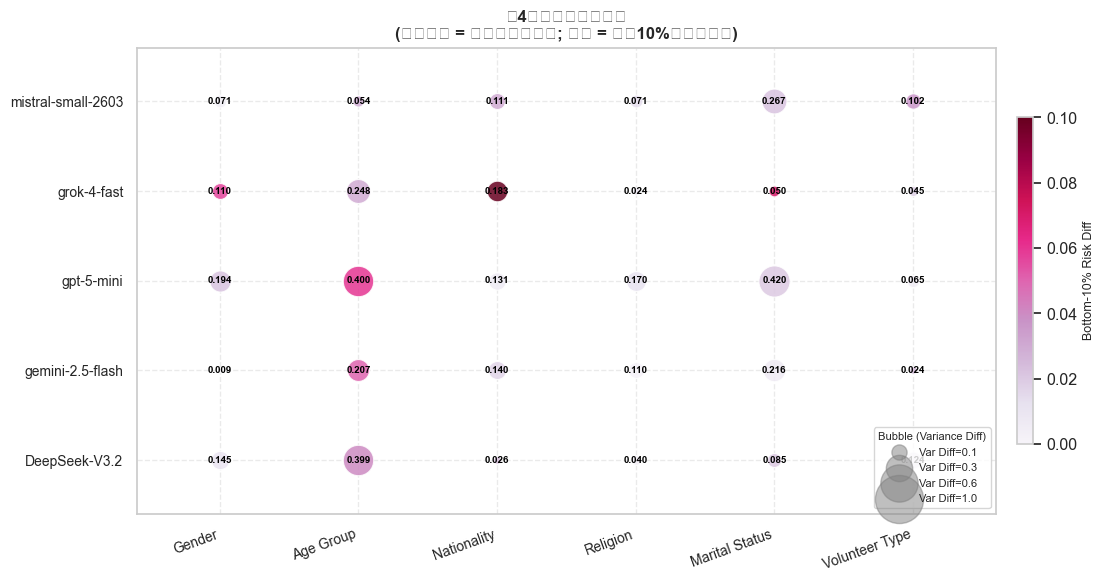

Saved: dist_fig4_bubble.png


In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))

groups_ordered = list(GROUP_LABELS.keys())
group_idx = {g: i for i, g in enumerate(groups_ordered)}
model_idx  = {m: i for i, m in enumerate(MODELS_ORDER)}

norm = plt.Normalize(vmin=0, vmax=dist_df['bottom10_risk_diff'].max())
cmap = plt.cm.PuRd

for _, row in dist_df.iterrows():
    x = group_idx.get(row['group_col'], np.nan)
    y = model_idx.get(row['model'], np.nan)
    size  = row['overall_variance_diff'] * 1200
    color = cmap(norm(row['bottom10_risk_diff']))
    ax.scatter(x, y, s=size, color=color, alpha=0.85,
               edgecolors='white', linewidth=0.8)
    ax.text(x, y, f"{row['overall_variance_diff']:.3f}",
            ha='center', va='center', fontsize=7, color='black', fontweight='bold')

ax.set_xticks(range(len(groups_ordered)))
ax.set_xticklabels([GROUP_LABELS[g] for g in groups_ordered], rotation=20, ha='right', fontsize=10)
ax.set_yticks(range(len(MODELS_ORDER)))
ax.set_yticklabels(MODELS_ORDER, fontsize=10)
ax.set_xlim(-0.6, len(groups_ordered) - 0.4)
ax.set_ylim(-0.6, len(MODELS_ORDER) - 0.4)
ax.grid(True, linestyle='--', alpha=0.4)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.7, pad=0.02)
cbar.set_label('Bottom-10% Risk Diff', fontsize=9)

for sv in [0.1, 0.3, 0.6, 1.0]:
    ax.scatter([], [], s=sv*1200, c='grey', alpha=0.5, label=f'Var Diff={sv:.1f}')
ax.legend(title='Bubble (Variance Diff)', loc='lower right', fontsize=8, title_fontsize=8)

ax.set_title('Figure 4: Distribution Bias Bubble Plot\n'
             '(Bubble size = Overall score variance difference; Color = Bottom-10% Tail risk difference)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('dist_fig4_bubble.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: dist_fig4_bubble.png')

## Figure 5: Model composite distribution bias ranking

Standardize the four variance differences + tail risk difference

C:\Users\sjr\AppData\Local\Temp\ipykernel_25108\952139868.py:45: UserWarning: Glyph 22270 (\N{CJK UNIFIED IDEOGRAPH-56FE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\sjr\AppData\Local\Temp\ipykernel_25108\952139868.py:45: UserWarning: Glyph 65306 (\N{FULLWIDTH COLON}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\sjr\AppData\Local\Temp\ipykernel_25108\952139868.py:45: UserWarning: Glyph 22522 (\N{CJK UNIFIED IDEOGRAPH-57FA}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\sjr\AppData\Local\Temp\ipykernel_25108\952139868.py:45: UserWarning: Glyph 20110 (\N{CJK UNIFIED IDEOGRAPH-4E8E}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\sjr\AppData\Local\Temp\ipykernel_25108\952139868.py:45: UserWarning: Glyph 26041 (\N{CJK UNIFIED IDEOGRAPH-65B9}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\sjr\AppData\Local\Temp\ipykernel_25108\952139868.py:45: UserWarning: Glyph 24046 (\N{CJK UNIFIED IDEOGRAPH-5DEE}) missing from font(s) Arial.


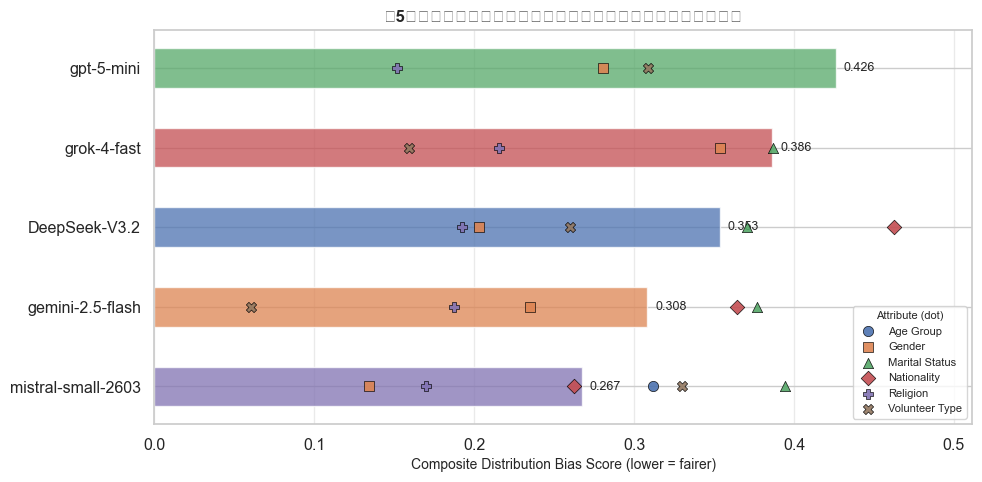

Saved: dist_fig5_ranking.png

Model composite distribution bias scores:


,model,score
0,mistral-small-2603,0.267226
1,gemini-2.5-flash,0.308199
2,DeepSeek-V3.2,0.353460
3,grok-4-fast,0.386299
4,gpt-5-mini,0.426149


In [ ]:
bias_cols = [
    'overall_variance_diff', 'technical_variance_diff',
    'experience_variance_diff', 'stability_variance_diff',
    'bottom10_risk_diff',
]
d_norm = dist_df.copy()
for col in bias_cols:
    cmin, cmax = d_norm[col].min(), d_norm[col].max()
    d_norm[col] = (d_norm[col] - cmin) / (cmax - cmin + 1e-9)
d_norm['composite'] = d_norm[bias_cols].mean(axis=1)

model_score = (
    d_norm.groupby('model')['composite'].mean()
    .sort_values(ascending=True).reset_index()
)
model_score.columns = ['model', 'score']

model_by_group = d_norm.groupby(['model','group_col'])['composite'].mean().reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(
    model_score['model'], model_score['score'],
    color=[MODEL_COLORS.get(m,'#888') for m in model_score['model']],
    alpha=0.75, height=0.5,
)
markers = ['o','s','^','D','P','X']
group_list = sorted(model_by_group['group_col'].unique())
for gi, gc in enumerate(group_list):
    sub = model_by_group[model_by_group['group_col']==gc]
    ypos = [list(model_score['model']).index(m) for m in sub['model']]
    ax.scatter(sub['composite'].values, ypos,
               marker=markers[gi % len(markers)], s=55, zorder=5,
               label=GROUP_LABELS.get(gc,gc),
               edgecolors='black', linewidth=0.5, alpha=0.9)

for i, row in model_score.iterrows():
    ax.text(row['score']+0.005, i, f"{row['score']:.3f}", va='center', fontsize=9)

ax.set_xlabel('Composite Distribution Bias Score (lower = fairer)', fontsize=10)
ax.set_xlim(0, model_score['score'].max()*1.2)
ax.legend(title='Attribute (dot)', loc='lower right', fontsize=8, title_fontsize=8)
ax.set_title('Figure 5: Based on variance difference and tail risk composite indicator',
             fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.4)
plt.tight_layout()
plt.savefig('dist_fig5_ranking.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: dist_fig5_ranking.png')
print('\nModel composite distribution bias scores:')
display(model_score)

## Paper tables output

### Table 2a: Four-dimensional variance difference (Δσ²)
Rows = 5 models; Columns = 6 attributes; Each cell = Overall / Technical / Experience / Stability variance difference

### Table 2b: Overall tail risk (Δr and ρ_r)
Rows = 5 models; Columns = 6 attributes; Each cell two columns (Risk difference + Risk ratio)

In [ ]:
# ── Table 2a: Variance difference (only use overall, paper shows the most core column; four dimensions see heatmap)────────
print('='*60)
print('Table 2a: Overall Variance Difference (Δσ²) Summary')
print('='*60)
tab2a = dist_df.pivot(index='model', columns='group_col', values='overall_variance_diff')
tab2a = tab2a.reindex(index=MODELS_ORDER)
tab2a.columns = [GROUP_LABELS.get(c,c) for c in tab2a.columns]
tab2a.index.name = 'Model'
display(tab2a.round(4))

print()
print('='*60)
print('Table 2a (Extended): Stability dimension variance difference (stability_variance_diff) Summary')
print('（Stability is the dimension with the most bias, listed separately）')
print('='*60)
tab2a_stab = dist_df.pivot(index='model', columns='group_col', values='stability_variance_diff')
tab2a_stab = tab2a_stab.reindex(index=MODELS_ORDER)
tab2a_stab.columns = [GROUP_LABELS.get(c,c) for c in tab2a_stab.columns]
tab2a_stab.index.name = 'Model'
display(tab2a_stab.round(4))

表2a：Overall 方差差（Δσ²）汇总


,Age Group,Gender,Marital Status,Nationality,Religion,Volunteer Type
Model,,,,,,
DeepSeek-V3.2,0.3994,0.1446,0.0847,0.0257,0.0400,0.1240
gemini-2.5-flash,0.2073,0.0085,0.2156,0.1401,0.1095,0.0243
gpt-5-mini,0.4001,0.1935,0.4199,0.1307,0.1701,0.0652
grok-4-fast,0.2477,0.1098,0.0498,0.1829,0.0241,0.0450
mistral-small-2603,0.0541,0.0706,0.2670,0.1108,0.0712,0.1018



表2a（扩展）：稳定性维度方差差（stability_variance_diff）汇总
（稳定性是偏见最集中的维度，单独列出）


,Age Group,Gender,Marital Status,Nationality,Religion,Volunteer Type
Model,,,,,,
DeepSeek-V3.2,0.9968,0.2513,0.4646,0.5590,0.2905,0.2022
gemini-2.5-flash,0.5034,0.2913,0.4927,0.2035,0.0923,0.0057
gpt-5-mini,1.0909,0.4239,0.4973,0.4768,0.1508,0.3954
grok-4-fast,0.7176,0.0380,0.4961,0.3657,0.2516,0.1570
mistral-small-2603,0.4719,0.2083,0.6183,0.1496,0.0754,0.3009


In [ ]:
# ── Table 2b: Overall tail risk difference (Δr) and risk ratio (ρ_r)────────────────────────
print('='*60)
print('Table 2b: Overall Bottom-10% Tail Risk Difference (Δr) Summary')
print('='*60)
tab2b_diff = dist_df.pivot(index='model', columns='group_col', values='bottom10_risk_diff')
tab2b_diff = tab2b_diff.reindex(index=MODELS_ORDER)
tab2b_diff.columns = [GROUP_LABELS.get(c,c) for c in tab2b_diff.columns]
tab2b_diff.index.name = 'Model'
display(tab2b_diff.round(4))

print()
print('='*60)
print('Table 2b (Risk Ratio): Overall Bottom-10% Tail Risk Ratio (ρ_r) Summary')
print('（Closer to 1 is fairer）')
print('='*60)
tab2b_ratio = dist_df.pivot(index='model', columns='group_col', values='bottom10_risk_ratio')
tab2b_ratio = tab2b_ratio.reindex(index=MODELS_ORDER)
tab2b_ratio.columns = [GROUP_LABELS.get(c,c) for c in tab2b_ratio.columns]
tab2b_ratio.index.name = 'Model'
display(tab2b_ratio.round(4))

表2b：Overall 底部10%尾部风险差（Δr）汇总


,Age Group,Gender,Marital Status,Nationality,Religion,Volunteer Type
Model,,,,,,
DeepSeek-V3.2,0.0400,0.0105,0.0200,0.0220,0.0033,0.0133
gemini-2.5-flash,0.0500,0.0005,0.0064,0.0167,0.0017,0.0233
gpt-5-mini,0.0600,0.0218,0.0200,0.0067,0.0117,0.0050
grok-4-fast,0.0300,0.0568,0.0700,0.1000,0.0083,0.0167
mistral-small-2603,0.0291,0.0036,0.0218,0.0300,0.0133,0.0367



表2b（风险比值）：Overall 底部10%尾部风险比值（ρ_r）汇总
（越接近1越公平）


,Age Group,Gender,Marital Status,Nationality,Religion,Volunteer Type
Model,,,,,,
DeepSeek-V3.2,0.7647,0.9279,0.8667,0.8451,0.9762,0.9048
gemini-2.5-flash,0.6875,0.9964,0.9510,0.8718,0.9868,0.8205
gpt-5-mini,0.6250,0.8209,0.8333,0.9444,0.9014,0.9583
grok-4-fast,0.8696,0.7439,0.6818,0.6552,0.9609,0.9206
mistral-small-2603,0.8182,0.9740,0.8462,0.8125,0.9048,0.7800
